In [ ]:
!pip install mediapipe
!pip install opencv-python
!pip install seaborn
!pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 4.5 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [ ]:
import os
import cv2
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from wordcloud import WordCloud
import mediapipe as mp

plt.style.use("ggplot")
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/Palm_Tarot_Project"

print("Folders in the project:")
print(os.listdir(project_path))

Folders in the project:
['tarot_dataset', 'hand_images', 'figures', 'outputs']


In [ ]:
hand_path = "/content/drive/MyDrive/Palm_Tarot_Project/hand_images"

print(os.listdir(hand_path))


['hand_dataset.zip']


In [ ]:
import os

hand_path = "/content/drive/MyDrive/Palm_Tarot_Project/hand_images"

# Show everything inside the folder
for item in os.listdir(hand_path):
    print(item)

hand_dataset.zip


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Palm_Tarot_Project/hand_images/hand_dataset.zip"

extract_path = "/content/drive/MyDrive/Palm_Tarot_Project/hand_images/hand_dataset"

# Create the folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract the ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully!")

✅ Dataset extracted successfully!


In [ ]:
import os

extract_path = "/content/drive/MyDrive/Palm_Tarot_Project/hand_images/hand_dataset"

print(os.listdir(extract_path))

['HandInfo.csv', 'Hands']


In [ ]:
import pandas as pd

csv_path = "/content/drive/MyDrive/Palm_Tarot_Project/hand_images/hand_dataset/HandInfo.csv"

df = pd.read_csv(csv_path)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [ ]:
import pandas as pd

csv_path = "/content/drive/MyDrive/Palm_Tarot_Project/hand_images/hand_dataset/HandInfo.csv"

df = pd.read_csv(csv_path)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [ ]:
df.head()

,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
0,0,27,male,fair,0,0,dorsal right,Hand_0000002.jpg,0
1,0,27,male,fair,0,0,dorsal right,Hand_0000003.jpg,0
2,0,27,male,fair,0,0,dorsal right,Hand_0000004.jpg,0
3,0,27,male,fair,0,0,dorsal right,Hand_0000005.jpg,0
4,0,27,male,fair,0,0,dorsal right,Hand_0000006.jpg,0


In [ ]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(11076, 9)


In [ ]:
df.columns

Index(['id', 'age', 'gender', 'skinColor', 'accessories', 'nailPolish',
       'aspectOfHand', 'imageName', 'irregularities'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11076 entries, 0 to 11075
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              11076 non-null  int64 
 1   age             11076 non-null  int64 
 2   gender          11076 non-null  object
 3   skinColor       11076 non-null  object
 4   accessories     11076 non-null  int64 
 5   nailPolish      11076 non-null  int64 
 6   aspectOfHand    11076 non-null  object
 7   imageName       11076 non-null  object
 8   irregularities  11076 non-null  int64 
dtypes: int64(5), object(4)
memory usage: 778.9+ KB


In [ ]:
df.describe(include='all')

,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
count,1.107600e+04,11076.000000,11076,11076,11076.000000,11076.000000,11076,11076,11076.000000
unique,NaN,NaN,2,4,NaN,NaN,4,11076,NaN
top,NaN,NaN,female,medium,NaN,NaN,dorsal right,Hand_0011744.jpg,NaN
freq,NaN,NaN,7109,6495,NaN,NaN,2892,1,NaN
mean,2.031043e+05,22.494583,NaN,NaN,0.289906,0.096334,NaN,NaN,0.014807
std,1.086731e+06,6.918974,NaN,NaN,0.453739,0.295063,NaN,NaN,0.120784
min,0.000000e+00,18.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,0.000000
25%,5.760000e+02,21.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,0.000000
50%,1.050000e+03,21.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,0.000000
75%,1.539250e+03,22.000000,NaN,NaN,1.000000,0.000000,NaN,NaN,0.000000


In [ ]:
df.isnull().sum()

,0
id,0
age,0
gender,0
skinColor,0
accessories,0
nailPolish,0
aspectOfHand,0
imageName,0
irregularities,0


In [ ]:
print(df.columns.tolist())

['id', 'age', 'gender', 'skinColor', 'accessories', 'nailPolish', 'aspectOfHand', 'imageName', 'irregularities']


In [ ]:
for col in df.columns:
    print(f"\n🔹 {col}")
    print(df[col].unique())



🔹 id
[      0     559      65     505     594    1585      55       8      25
      54    1515      81    1073      19      13      11      63    1592
     572    1593       4    1023      45     570      61      62      57
     529      27      28      53    1535    1074      64    1069    1008
      10     514    1509      41    1022    1081    1506    1528     504
      38    1519    1517    1518    1520      67    1503     543    1070
      86    1555     574     525    1545    1020    1537    1533    1540
    1024    1543    1527    1505    1588    1549    1002    1019    1544
     546    1026    1541    1018    1036    1571    1564    1569    1567
    1568    1566    1039    1013    1032    1034    1035    1066    1033
    1080    1050    1558    1021    1059    1042    1061     576    1067
    1041    1529    1557    1079     588     587     586    1547    1037
    1559      12    1553    1058    1560    1510    1556    1587    1029
    1028    1051     509    1532     534    1

In [ ]:
for col in ['gender', 'skinColor', 'accessories', 'nailPolish', 'aspectOfHand']:
    print("\n", "="*40)
    print(col)
    print(df[col].value_counts())


gender
gender
female    7109
male      3967
Name: count, dtype: int64

skinColor
skinColor
medium       6495
fair         3493
dark          758
very fair     330
Name: count, dtype: int64

accessories
accessories
0    7865
1    3211
Name: count, dtype: int64

nailPolish
nailPolish
0    10009
1     1067
Name: count, dtype: int64

aspectOfHand
aspectOfHand
dorsal right    2892
palmar right    2813
dorsal left     2788
palmar left     2583
Name: count, dtype: int64


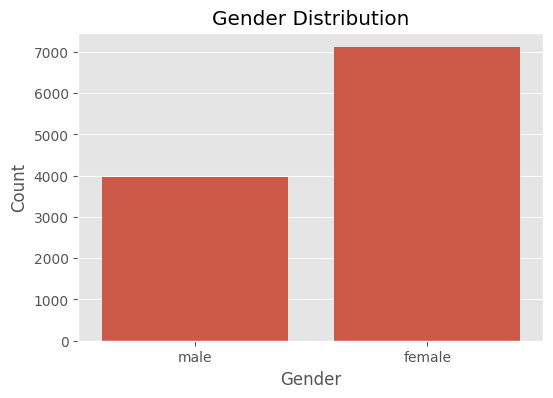

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(data=df, x='gender')

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

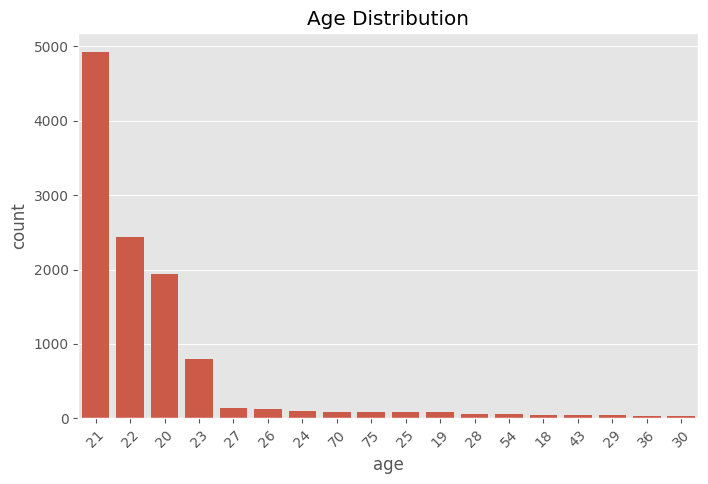

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='age', order=df['age'].value_counts().index)
plt.title("Age Distribution")
plt.xticks(rotation=45)
plt.show()

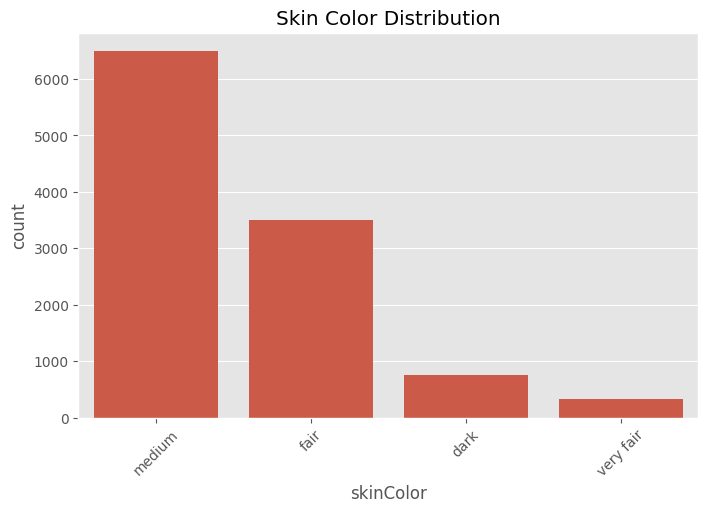

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='skinColor', order=df['skinColor'].value_counts().index)
plt.title("Skin Color Distribution")
plt.xticks(rotation=45)
plt.show()

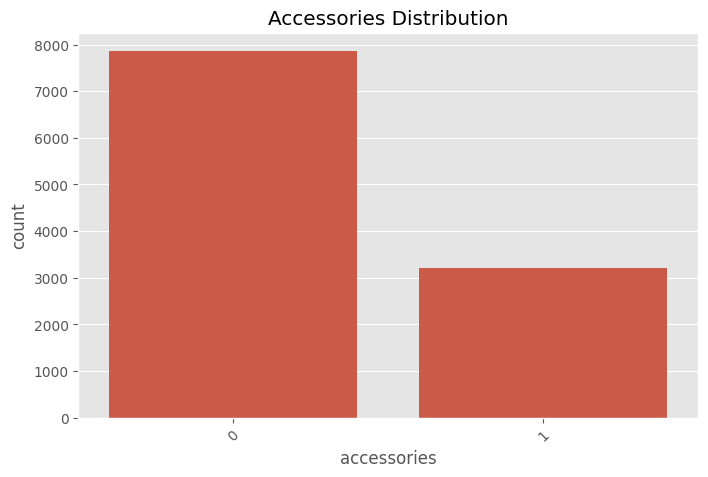

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='accessories', order=df['accessories'].value_counts().index)
plt.title("Accessories Distribution")
plt.xticks(rotation=45)
plt.show()

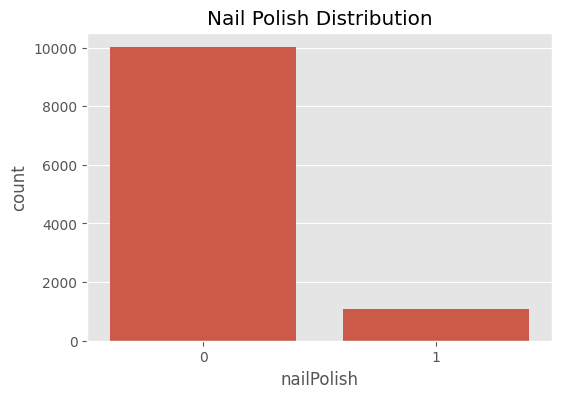

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='nailPolish')
plt.title("Nail Polish Distribution")
plt.show()

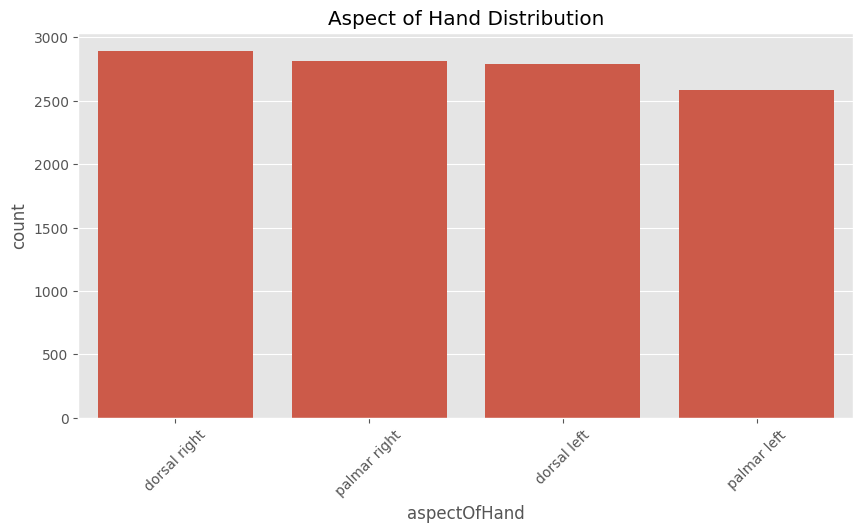

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='aspectOfHand', order=df['aspectOfHand'].value_counts().index)
plt.title("Aspect of Hand Distribution")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.isnull().sum()

,0
id,0
age,0
gender,0
skinColor,0
accessories,0
nailPolish,0
aspectOfHand,0
imageName,0
irregularities,0


In [ ]:
import os

image_folder = "/content/drive/MyDrive/Palm_Tarot_Project/hand_images/hand_dataset/Hands/Hands"

print(os.listdir(image_folder)[:10])

['Hand_0000002.jpg', 'Hand_0000003.jpg', 'Hand_0000004.jpg', 'Hand_0000005.jpg', 'Hand_0000006.jpg', 'Hand_0000007.jpg', 'Hand_0000008.jpg', 'Hand_0000009.jpg', 'Hand_0000010.jpg', 'Hand_0000011.jpg']


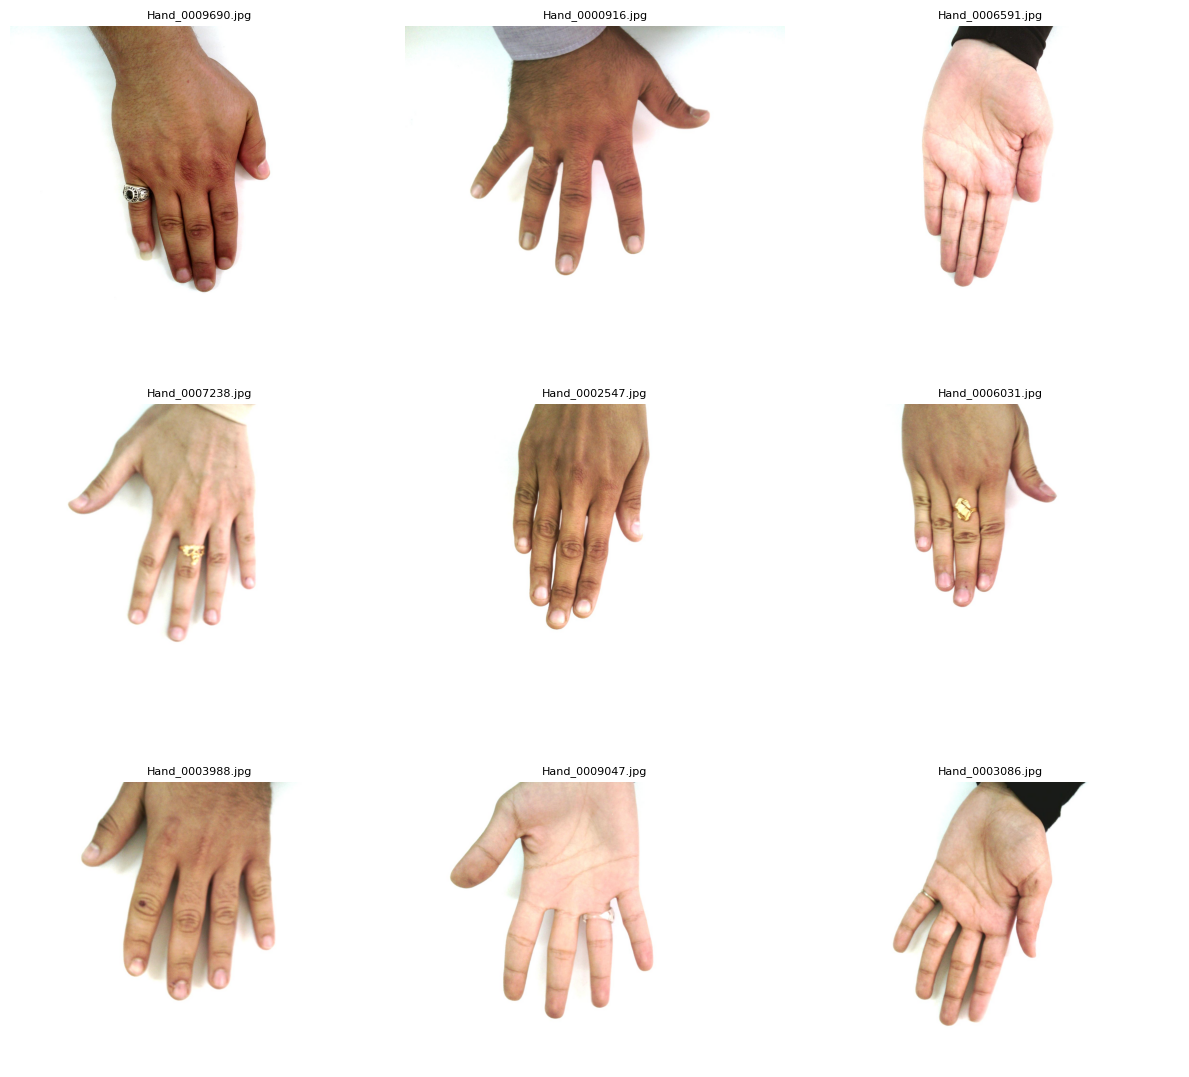

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Path to the images
image_folder = "/content/drive/MyDrive/Palm_Tarot_Project/hand_images/hand_dataset/Hands/Hands"

# Get all image files
images = [img for img in os.listdir(image_folder)
          if img.endswith(('.jpg', '.jpeg', '.png'))]

# Display 9 random images
plt.figure(figsize=(12, 12))

for i in range(9):
    img_name = random.choice(images)
    img_path = os.path.join(image_folder, img_name)

    img = Image.open(img_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(img_name, fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

# MediaPipe Hand Landmark Extraction

In [ ]:
import mediapipe as mp
import cv2
import os
import pandas as pd
import numpy as np

In [ ]:
import mediapipe as mp
print(mp.__version__)

0.10.35


In [ ]:
import mediapipe as mp

print(dir(mp))

['Image', 'ImageFormat', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'tasks']


Tarot dataset EDA


In [ ]:
import os
tarot_path="/content/drive/MyDrive/Palm_Tarot_Project/tarot_dataset"
print(os.listdir(tarot_path))

['tarot-images.json']


Dataset Loaded Successfully!

Type of Data: <class 'dict'>

Keys:
dict_keys(['description', 'cards'])

Total Number of Cards: 78

First Five Records


,name,number,arcana,suit,img,fortune_telling,keywords,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,meanings.light,meanings.shadow,Astrology,Affirmation
0,The Fool,0,Major Arcana,Trump,m00.jpg,"[Watch for new projects and new beginnings, Pr...","[freedom, faith, inexperience, innocence]",The Divine Madman,Aleph/Ox/1,0 (off the scale; pure potential),Air,Adam before the fall. Christ as a wandering ho...,[What would I do if I felt free to take a leap...,"[Freeing yourself from limitation, Expressing ...","[Being gullible and naive, Taking unnecessary ...",NaN,NaN
1,The Magician,1,Major Arcana,Trump,m01.jpg,"[A powerful man may play a role in your day, Y...","[capability, empowerment, activity]",The Ego/The Self,Beth/House/2,"1 (origins, unity, seeds)",The Sun/Mercury,"Thoth, the Egyptian god of wisdom, known to th...","[What am I empowered to do?, How might my abil...","[Taking appropriate action, Receiving guidance...","[Inflating your own ego, Abusing talents, Mani...",NaN,NaN
2,The High Priestess,2,Major Arcana,Trump,m02.jpg,"[A mysterious woman arrives, A sexual secret m...","[intuition, reflection, purity, initiation]",The Virgin/The Maiden,Gimel/Camel/3,"2 (division, debate, duality)",The Moon,"The feminine aspect of divinity, particularity...","[What might a rebel against tradition do?, Wha...","[Listening to your feelings and intuitions, Ex...","[Being aloof, Obsessing on secrets and conspir...",NaN,NaN
3,The Empress,3,Major Arcana,Trump,m03.jpg,"[Pregnancy is in the cards, An opportunity to ...","[fertility, productivity, ripeness, nurturing]",The Mother,Daleth/Door/4,"3 (expression, productivity, output)",Venus,"Gaia, Mother Earth, Ishtar, DemeterÑmature, re...",[What would a concerned and capable mother do?...,"[Nurturing yourself and others, Bearing fruit,...","[Overindulging, Being greedy, Smothering someo...",NaN,NaN
4,The Emperor,4,Major Arcana,Trump,m04.jpg,"[A father figure arrives, A new employer or au...","[authority, regulation, direction, structure]",The Father,"He[as]/Window/5, or in some decks, Tzaddi/Fish...","4 (stability, equality, persistence)",Mars/Aries,"Masculine gods, including the Hebrew God, the ...",[How does the issue of control or regulation i...,"[Exercising authority, Defining limits, Direct...","[Micromanaging, Crushing the creativity of oth...",NaN,NaN



Shape
(78, 17)

Columns
['name', 'number', 'arcana', 'suit', 'img', 'fortune_telling', 'keywords', 'Archetype', 'Hebrew Alphabet', 'Numerology', 'Elemental', 'Mythical/Spiritual', 'Questions to Ask', 'meanings.light', 'meanings.shadow', 'Astrology', 'Affirmation']

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                78 non-null     object
 1   number              78 non-null     object
 2   arcana              78 non-null     object
 3   suit                78 non-null     object
 4   img                 78 non-null     object
 5   fortune_telling     78 non-null     object
 6   keywords            78 non-null     object
 7   Archetype           22 non-null     object
 8   Hebrew Alphabet     22 non-null     object
 9   Numerology          62 non-null     object
 10  Elemental           38 non-nu

,name,number,arcana,suit,img,fortune_telling,keywords,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,meanings.light,meanings.shadow,Astrology,Affirmation
count,78,78,78,78,78,78,78,22,22,62,38,22,78,78,78,40,56
unique,78,22,2,5,78,78,78,22,22,33,38,22,78,78,78,40,56
top,The Fool,1,Minor Arcana,Trump,m00.jpg,"[Watch for new projects and new beginnings, Pr...","[freedom, faith, inexperience, innocence]",The Divine Madman,Aleph/Ox/1,"4 (The Status Quo: stability, equality, persis...",Air,Adam before the fall. Christ as a wandering ho...,[What would I do if I felt free to take a leap...,"[Freeing yourself from limitation, Expressing ...","[Being gullible and naive, Taking unnecessary ...","Cancer, Scorpio, Pisces","""I listen to the counsel of my heart."""
freq,1,5,56,22,1,1,1,1,1,4,1,1,1,1,1,1,1


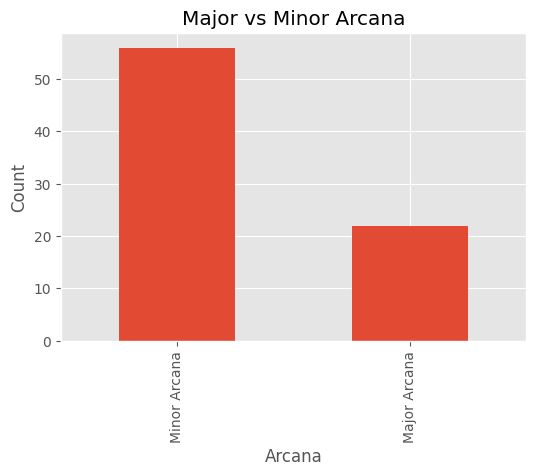

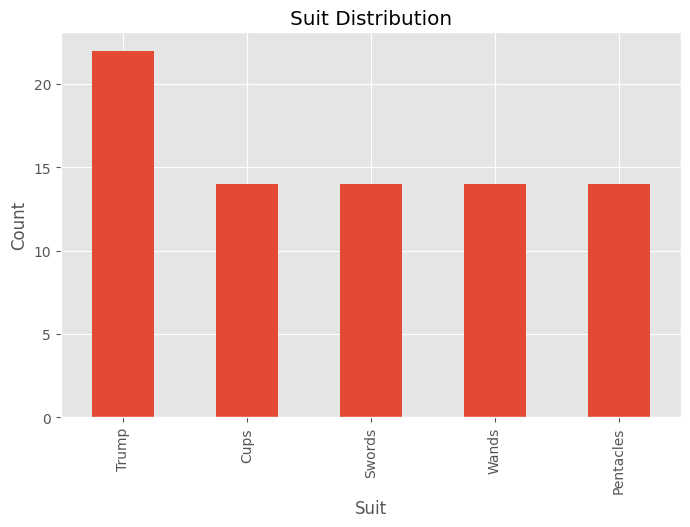


First 10 Card Names
0              The Fool
1          The Magician
2    The High Priestess
3           The Empress
4           The Emperor
5        The Hierophant
6            The Lovers
7           The Chariot
8              Strength
9            The Hermit
Name: name, dtype: object

Top 20 Most Frequent Words

to                   398
the                  357
of                   278
nan                  277
a                    261
your                 216
in                   191
and                  188
or                   173
you                  149
i                    127
for                  111
with                 91
what                 90
my                   78
arcana               77
on                   71
can                  67
is                   64
be                   63

Tarot Dataset EDA Completed Successfully!


In [ ]:
# ==========================================
# TAROT DATASET - COMPLETE EDA
# ==========================================

import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# ----------------------------
# Load JSON File
# ----------------------------

json_path = "/content/drive/MyDrive/Palm_Tarot_Project/tarot_dataset/tarot-images.json"

with open(json_path, "r", encoding="utf-8") as f:
    tarot = json.load(f)

print("Dataset Loaded Successfully!")

# ----------------------------
# Explore JSON Structure
# ----------------------------

print("\nType of Data:", type(tarot))

if isinstance(tarot, dict):
    print("\nKeys:")
    print(tarot.keys())

    # Usually cards are stored under 'cards'
    if "cards" in tarot:
        cards = tarot["cards"]
    else:
        cards = list(tarot.values())[0]

elif isinstance(tarot, list):
    cards = tarot

print("\nTotal Number of Cards:", len(cards))

# ----------------------------
# Convert to DataFrame
# ----------------------------

df = pd.json_normalize(cards)

print("\nFirst Five Records")
display(df.head())

print("\nShape")
print(df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# ----------------------------
# Summary Statistics
# ----------------------------

display(df.describe(include='all'))

# ----------------------------
# Card Type Distribution
# ----------------------------

if 'arcana' in df.columns:

    plt.figure(figsize=(6,4))

    df['arcana'].value_counts().plot(kind='bar')

    plt.title("Major vs Minor Arcana")

    plt.xlabel("Arcana")

    plt.ylabel("Count")

    plt.show()

# ----------------------------
# Suit Distribution
# ----------------------------

if 'suit' in df.columns:

    plt.figure(figsize=(8,5))

    df['suit'].fillna("Major Arcana").value_counts().plot(kind='bar')

    plt.title("Suit Distribution")

    plt.xlabel("Suit")

    plt.ylabel("Count")

    plt.show()

# ----------------------------
# Card Names
# ----------------------------

if 'name' in df.columns:

    print("\nFirst 10 Card Names")

    print(df['name'].head(10))

# ----------------------------
# Meaning Length Analysis
# ----------------------------

if 'meaning_up' in df.columns:

    df['Meaning_Length'] = df['meaning_up'].astype(str).apply(len)

    plt.figure(figsize=(8,5))

    plt.hist(df['Meaning_Length'], bins=15)

    plt.title("Distribution of Upright Meaning Length")

    plt.xlabel("Characters")

    plt.ylabel("Frequency")

    plt.show()

# ----------------------------
# Word Frequency
# ----------------------------

text = ""

for col in df.columns:

    if df[col].dtype == object:

        text += " ".join(df[col].astype(str).tolist())

words = text.lower().split()

common = Counter(words)

print("\nTop 20 Most Frequent Words\n")

for word, count in common.most_common(20):

    print(f"{word:20} {count}")

print("\nTarot Dataset EDA Completed Successfully!")